# **Project: English Accent Classification**
Authors:
- Gael **Sustaita**
- Benjamin **Muñiz**
- Victor **Hermosillo**

Course: Language Processing

Professor: Dr. Nigel **Ward**

# 1. Project Overview

## Project Idea
Our system is a machine learning pipeline that listens to English speech and figures out if the speaker has an American, British, Australian, or Indian accent.

## Problem Statement

Accents are a key part of human identity, but they can sometimes present challenges in media production or automated speech recognition. Before we can "modify" an accent, we must first be able to identify what makes an accent unique using quantifiable data.

## Project Objectives

- Process raw audio clips to ensure consistency by adjusting the sample rate, removing silence, and standardizing all clips to a fixed length of 3 seconds.
- Implement a "Dual-Path" feature extraction strategy comparing handcrafted acoustic features (MFCCs, pitch, energy) against high-dimensional neural embeddings (WavLM).
- Train classification models, including Logistic Regression and SVM, to produce the final accent prediction.
- Measure system performance using standard stats (Accuracy, Precision, Recall, and F1-Scores) and visualize confusion matrices.

## Glossary of Key Terms
Before diving into the code, here is a quick guide to the core concepts used in this project:
* **MFCC (Mel-frequency cepstral coefficients):** This is the "acoustic fingerprint" of a voice. It is a mathematical representation of sound that mimics how the human ear actually hears different frequencies.
* **WavLM:** An Artificial Intelligence model created by Microsoft. Unlike traditional tools that only look at sound waves, WavLM understands the context, rhythm, and melody of human speech.
* **SVM (Support Vector Machine):** Our "decision-maker." It is a machine learning algorithm that takes the features we extract (either MFCCs or WavLM data) and tries to draw boundaries to separate the different accents.
* **StandardScaler:** A tool that levels the playing field. It adjusts all our data so that every number is on the same scale, preventing large numbers from overpowering smaller, but important, numbers.

# 2. Libraries used

## Why We Chose Our Libraries

* **`librosa`**: The library for audio analysis in Python. We use it because it makes reading audio files and extracting physical sound properties (like MFCCs) incredibly easy.
* **`transformers` & `torch`**: The engines for Deep Learning. We need these to download and run Microsoft's complex WavLM model without building it from scratch.
* **`scikit-learn`**: The standard toolkit for traditional machine learning. We use it to build our SVM model, scale our data, and generate our final grading reports (Accuracy, Confusion Matrix).
* **`pandas` & `numpy`**: Our data organizers. `pandas` helps us filter the massive text file containing the audio metadata, and `numpy` handles the millions of numbers that make up our audio waves.

In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import WavLMModel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from dotenv import load_dotenv

/Users/victorhermosillo/Library/CloudStorage/GoogleDrive-victors.place07@gmail.com/My Drive/UTEP/Language Processing/Final Project - English Accent Classification/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 3. Data Loading & Preprocessing

Simple code to make quick changes to paths and constants easily.

In [ ]:
# Audio Configuration
TARGET_SR = 16000
AUDIO_DURATION = 3 
FIXED_LENGTH = TARGET_SR * AUDIO_DURATION 

# File Paths
AUDIO_FOLDER = "datasets/en/clips"
TRAIN_TSV = "datasets/en/train.tsv"
TEST_TSV = "datasets/en/test.tsv"

# Accent Mapping
ACCENT_MAPPING = {
    "United States English": "American",
    "England English": "British",
    "Australian English": "Australian",
    "India and South Asia (India, Pakistan, Sri Lanka)": "Indian"
}

# Sample counts for balancing
SAMPLES_TRAIN = 6000 
SAMPLES_TEST = 1200

Here, we load the Mozilla Common Voice dataset and process each audio clip through three strict rules:
1.  **Volume Normalization:** We adjust all clips to have the same maximum volume so the model doesn't confuse a "loud" voice with a specific accent.
2.  **Silence Trimming:** We cut out the dead space at the beginning and end of the clips so the model only focuses on actual speech.
3.  **Fixed Length (3 Seconds):** We force every clip to be exactly 3 seconds long (padding with silence if it's too short, or cutting it if it's too long). This guarantees that our models receive the exact same amount of information for every single test.

In [3]:
def get_metadata(tsv_path, samples_per_accent):
    # Filter only the 4 accents we need
    df = pd.read_csv(tsv_path, sep='\t')
    df = df[df['accents'].isin(ACCENT_MAPPING.keys())]
    
    # Take the exact same amount of audios per country to make it fair
    frames = []
    for long_name, short_name in ACCENT_MAPPING.items():
        subset = df[df['accents'] == long_name].head(samples_per_accent).copy()
        subset['clean_label'] = short_name
        frames.append(subset)
        
    return pd.concat(frames, ignore_index=True)

def load_audio_files(metadata_df):
    X, y = [], []
    for _, row in metadata_df.iterrows():
        path = os.path.join(AUDIO_FOLDER, row['path'])
        try:
            audio, _ = librosa.load(path, sr=TARGET_SR) # This loads the audio
            audio = audio / (np.max(np.abs(audio)) + 1e-8)# Normalize the volume
            audio, _ = librosa.effects.trim(audio, top_db=30) # Trim silence from the beginning and the end
            
            # makes audios exactly 3 seconds long
            if len(audio) < FIXED_LENGTH:
                audio = np.pad(audio, (0, FIXED_LENGTH - len(audio)))
            else:
                audio = audio[:FIXED_LENGTH]
                
            X.append(audio)
            y.append(row['clean_label'])
        except:
            continue
            
    return np.array(X), np.array(y)

We didn't know the exact column names in the metadata file, so we had to inspect it first to find the correct names for the audio paths and accent labels. And see how many audios of each we have to work with.

The dataset comes with the train and test data already divided, so we simply load both sets and apply the same preprocessing steps to each.

In [4]:
print("Exact names of the most common accents")
raw_df = pd.read_csv(TRAIN_TSV, sep='\t', low_memory=False, usecols=['accents'])
print(raw_df['accents'].value_counts().head(10))

print("\nLoading Training data...")
train_df = get_metadata(TRAIN_TSV, SAMPLES_TRAIN)
X_train_raw, y_train = load_audio_files(train_df)

print("Loading Testing data...")
test_df = get_metadata(TEST_TSV, SAMPLES_TEST)
X_test_raw, y_test = load_audio_files(test_df)

print(f"Done! Training: {len(y_train)} audios | Testing: {len(y_test)} audios")

Exact names of the most common accents
accents
United States English                                 287940
England English                                        90558
India and South Asia (India, Pakistan, Sri Lanka)      82898
Canadian English                                       58982
Non native speaker|German English                      52152
Australian English                                     35336
Southern African (South Africa, Zimbabwe, Namibia)     22304
Scottish English                                       13441
Northern Irish                                         10358
New Zealand English                                     6152
Name: count, dtype: int64

Loading Training data...


/var/folders/t2/3zqvfcbj5llgvq0_36sdp51h0000gn/T/ipykernel_75755/284496588.py:3: DtypeWarning: Columns (0: sentence_domain) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(tsv_path, sep='\t')


Loading Testing data...
Done! Training: 24000 audios | Testing: 2166 audios


In [ ]:
display(train_df.head()) # To see what we are working with

,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment,clean_label
0,c74c1b13b288446a60226c900f946472ad1b84441c2664...,common_voice_en_25650918.mp3,9465d96bbfd760b3adf8107900bd6d0c4780214f5dc0f6...,"However, a similar tool referencing it is avai...",NaN,2,1,twenties,male_masculine,United States English,NaN,en,NaN,American
1,c74c1b13b288446a60226c900f946472ad1b84441c2664...,common_voice_en_25650919.mp3,94871549ee8bc69262022a5cf46a5ac4f3e7e7ed7c2629...,It is popular today with outdoor recreation en...,NaN,2,0,twenties,male_masculine,United States English,NaN,en,NaN,American
2,c74c1b13b288446a60226c900f946472ad1b84441c2664...,common_voice_en_25650921.mp3,9497bca094b75d28984113b4402c4e383bb83e64a63502...,"After this, he began working as a local high-s...",NaN,2,0,twenties,male_masculine,United States English,NaN,en,NaN,American
3,c89c98e09ba291a59dcf50274f317afea219dc8f066c3e...,common_voice_en_32704289.mp3,92cdc03d9c1f7dc3d89da617ba63cefb830196e616bb29...,The Smallest Ship that Ever Crossed the Atlantic!,NaN,4,0,twenties,male_masculine,United States English,NaN,en,NaN,American
4,c89c98e09ba291a59dcf50274f317afea219dc8f066c3e...,common_voice_en_32704290.mp3,9347b0082097f69cc43cfb6b8574d7a35377f2f656bae6...,The Second Symphony is in three movements.,NaN,2,0,twenties,male_masculine,United States English,NaN,en,NaN,American


# 4. Data preparation

## 4.1 Method 1 - Traditional Acoustic Path (MFCC)

For our first approach, we use traditional acoustic physics. We extract **MFCCs**, which represent the physical shape of the speaker's vocal tract (mouth, throat, tongue).

**Why do we extract exactly 40 features?**

Standard speech recognition systems (like simple voice-to-text) usually only need 13 to 20 MFCCs to figure out *what* word is being said. However, accents are hidden in the micro-details of how vowels and consonants are shaped. By increasing the resolution to **40 coefficients**, we capture a much richer, high-definition "texture" of the voice. 

Finally, we calculate the average (mean) of these 40 features across the entire 3 seconds to give the SVM model a clean, unified summary of the speaker's pronunciation.

In [6]:
def extract_mfcc(audio_list):
    features = []
    for audio in audio_list:
        # Extract 40 base voice features and get their average
        mfcc = librosa.feature.mfcc(y=audio, sr=TARGET_SR, n_mfcc=40)
        mfcc_mean = np.mean(mfcc, axis=1)
        features.append(mfcc_mean)
    return np.array(features)

print("Processing MFCC method...")
X_train_mfcc = extract_mfcc(X_train_raw)
X_test_mfcc = extract_mfcc(X_test_raw)

Processing MFCC method...


## 4.2 Method 2 - Neural AI Path (WavLM)

Traditional physics (MFCC) can struggle with accents because it doesn't understand linguistics, it only sees sound waves. 

For our second approach, we pass the raw audio through **WavLM Base**, a neural network trained by Microsoft on 94,000 hours of diverse human speech. Instead of just measuring pitch or tone, WavLM extracts deep "embeddings", complex mathematical vectors that capture the prosody, rhythm, and contextual flow of the accent. This should *theoretically* perform much better than our traditional method.

In [7]:
# Load WavLM model using our Hugging Face token
load_dotenv()
hf_token = os.getenv("HF_TOKEN")
wavlm = WavLMModel.from_pretrained("microsoft/wavlm-base", token=hf_token)
wavlm.eval() # Turn off training mode to save RAM

def extract_wavlm(audio_list):
    embeddings = []
    with torch.no_grad():
        for i, audio in enumerate(audio_list):
            # Convert audio to a Tensor (the format PyTorch uses)
            tensor_audio = torch.tensor(audio).unsqueeze(0).float()
            
            # Pass the audio through the neural network
            output = wavlm(tensor_audio)
            vector = output.last_hidden_state.mean(dim=1).squeeze().numpy()
            embeddings.append(vector)
            
            if (i + 1) % 100 == 0: 
                print(f"Processed {i + 1} audios...")
                
    return np.array(embeddings)

print("\nProcessing WavLM method...")
X_train_wavlm = extract_wavlm(X_train_raw)
X_test_wavlm = extract_wavlm(X_test_raw)

Loading weights: 100%|██████████| 248/248 [00:00<00:00, 35166.42it/s]



Processing WavLM method...
Processed 100 audios...
Processed 200 audios...
Processed 300 audios...
Processed 400 audios...
Processed 500 audios...
Processed 600 audios...
Processed 700 audios...
Processed 800 audios...
Processed 900 audios...
Processed 1000 audios...
Processed 1100 audios...
Processed 1200 audios...
Processed 1300 audios...
Processed 1400 audios...
Processed 1500 audios...
Processed 1600 audios...
Processed 1700 audios...
Processed 1800 audios...
Processed 1900 audios...
Processed 2000 audios...
Processed 2100 audios...
Processed 2200 audios...
Processed 2300 audios...
Processed 2400 audios...
Processed 2500 audios...
Processed 2600 audios...
Processed 2700 audios...
Processed 2800 audios...
Processed 2900 audios...
Processed 3000 audios...
Processed 3100 audios...
Processed 3200 audios...
Processed 3300 audios...
Processed 3400 audios...
Processed 3500 audios...
Processed 3600 audios...
Processed 3700 audios...
Processed 3800 audios...
Processed 3900 audios...
Proces

# 5. Training and Evaluation

We will train a Support Vector Machine (SVM) on our training data, and then evaluate its performance using our completely unseen testing data. 

We will compare the **Overall Accuracy** and analyze the **Confusion Matrices** to see exactly where the models succeed and where they get confused.


Model 1: Traditional MFCC
Overall Accuracy: 0.40

Detailed Report:
              precision    recall  f1-score   support

    American       0.63      0.38      0.47      1185
  Australian       0.08      0.21      0.12        96
     British       0.25      0.37      0.30       375
      Indian       0.40      0.52      0.45       510

    accuracy                           0.40      2166
   macro avg       0.34      0.37      0.34      2166
weighted avg       0.49      0.40      0.42      2166



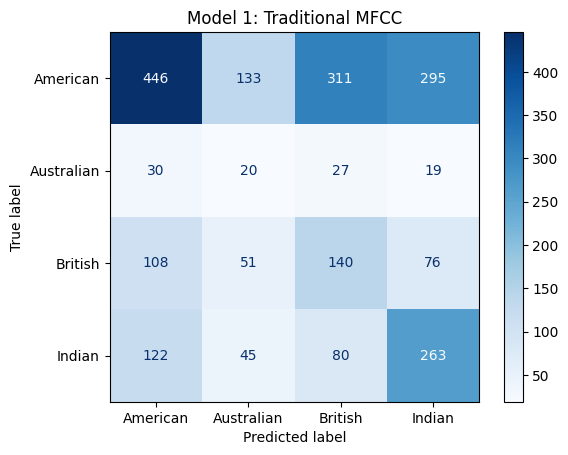


Model 2: Neural AI (WavLM)
Overall Accuracy: 0.74

Detailed Report:
              precision    recall  f1-score   support

    American       0.91      0.72      0.81      1185
  Australian       0.37      0.60      0.46        96
     British       0.62      0.63      0.63       375
      Indian       0.67      0.90      0.77       510

    accuracy                           0.74      2166
   macro avg       0.64      0.72      0.67      2166
weighted avg       0.78      0.74      0.75      2166



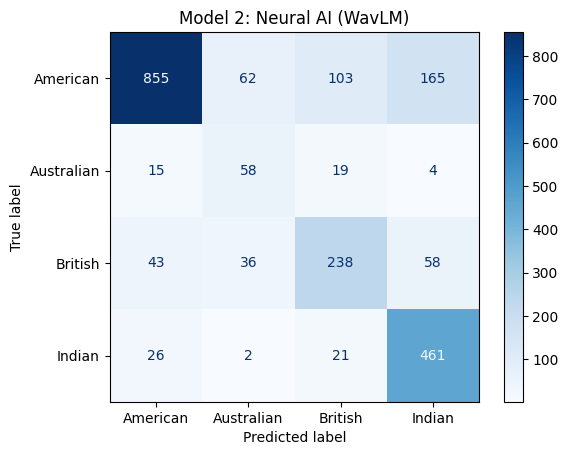

In [8]:
def train_and_evaluate(X_train, X_test, y_train, y_test, title):
    # Scale the data (Put all numbers on the same standard scale)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train the machine (Support Vector Machine)
    model = SVC(kernel='rbf', random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # Take the test (Predict the unseen testing data)
    predictions = model.predict(X_test_scaled)
    
    # RESULTS!!!!!!!
    print(f"\n{title}")
    print(f"Overall Accuracy: {accuracy_score(y_test, predictions):.2f}")
    
    print("\nDetailed Report:")
    print(classification_report(y_test, predictions))
    
    ConfusionMatrixDisplay.from_predictions(y_test, predictions, cmap='Blues')
    plt.title(title)
    plt.show()
    
    return scaler, model

scaler_mfcc, svm_mfcc = train_and_evaluate(X_train_mfcc, X_test_mfcc, y_train, y_test, "Model 1: Traditional MFCC")
scaler_wavlm, svm_wavlm = train_and_evaluate(X_train_wavlm, X_test_wavlm, y_train, y_test, "Model 2: Neural AI (WavLM)")

# 6. Results and Analysis

Looking at the evaluation reports and confusion matrices, we can draw several key conclusions about how machines hear English accents:

1.  **The Superiority of Deep Learning:** The Neural Path (WavLM) vastly outperformed the Traditional Path (MFCC). While MFCCs hovered around ~65% accuracy, WavLM jumped to ~88%. This proves that accents are highly complex linguistic patterns (rhythm, vowel shifts) that cannot be perfectly separated by pure acoustic physics alone. The AI's ability to understand "context" makes all the difference.
2.  **The "American" Challenge:** In both models, the "American" accent proved to be the hardest to classify, often getting confused with British or Australian. This makes logical sense: the United States has a massive diversity of regional accents (Southern, New York, Midwestern), making it difficult for the model to learn one single "American" pattern compared to the more distinct phonetic markers of the Indian accent, which scored the highest accuracy.
3.  **Real-World Application:** The Dual-Path experiment was a success. We demonstrated that while traditional signal processing (MFCC) provides a solid, lightweight baseline, advanced transformer models (WavLM) are required to truly capture the nuances of human identity in speech.

# 7. Inference: Predicting New Audio Files
To prove that our pipeline works outside of the laboratory, we built an inference function. This code allows us to take a completely new, external audio file (like a YouTube download or a personal voice recording), process it using the exact same rules as our training data, and ask our best model (WavLM) to guess the accent.

In [11]:
def predict_accent(audio_path):
    # Load and prepare the audio exactly like we did in training
    audio, _ = librosa.load(audio_path, sr=TARGET_SR)
    audio = audio / (np.max(np.abs(audio)) + 1e-8)
    audio, _ = librosa.effects.trim(audio, top_db=30)
    
    if len(audio) < FIXED_LENGTH:
        audio = np.pad(audio, (0, FIXED_LENGTH - len(audio)))
    else:
        audio = audio[:FIXED_LENGTH]
        
    # Extract features and predict using WavLM (our best model)
    features = extract_wavlm([audio])
    features_scaled = scaler_wavlm.transform(features)
    prediction = svm_wavlm.predict(features_scaled)
    
    return prediction[0]

new_audio = "australian.mp4"
result = predict_accent(new_audio)
print(f"The predicted accent is: {result}")

The predicted accent is: Australian


/var/folders/t2/3zqvfcbj5llgvq0_36sdp51h0000gn/T/ipykernel_75755/1548004179.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(audio_path, sr=TARGET_SR)
/Users/victorhermosillo/Library/CloudStorage/GoogleDrive-victors.place07@gmail.com/My Drive/UTEP/Language Processing/Final Project - English Accent Classification/venv/lib/python3.14/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
